# EP Leverage Throttle v5

**Entropy Pooling + Fully Flexible Resampling → CVaR → Leverage**

11 state variables (macro + technical + volume), rolling 504d P25/P75 partitioning.
Joint EP (mean equality + variance inequality per variable) → FFR 21d ahead → CVaR.
Rolling 504d CVaR percentile rank → leverage 0.5x / 1.0x / 1.5x. SMA 200 bear override.

Signal at close t applied at t+1. TC = 10bps per unit leverage change.

Phases: 0 (calibration 504d) → 1 (CVaR collection 504d) → 2 (live).
Data starts 2007-03-01 (DXY bottleneck). Live from ~2011-03.

In [1]:
# ── Dependencies ─────────────────────────────────────────────────
import subprocess, sys

def ensure(pkg, pip_name=None):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name or pkg, '-q'])

ensure('yfinance')
ensure('fredapi')
ensure('fortitudo', 'fortitudo.tech')

import numpy as np
import pandas as pd
import yfinance as yf
import fortitudo.tech as ft
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from fredapi import Fred
from scipy.stats import gaussian_kde
import warnings, time
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


## 1 — Configuration

In [2]:
# ── API keys ──────────────────────────────────────────────────────
FRED_KEY = 'f887507374b463ac1fcc8e0ad01cbed3'

# ── Data ──────────────────────────────────────────────────────────
DATA_START = '2005-01-01'       # fetch early for rolling warmup
TRIM_START = '2007-03-01'       # all variables available from here

# ── State classification ──────────────────────────────────────────
STATE_VARS = [
    'sp500_growth', 'T10Y3M', 'T10YIE', 'DFII10', 'DXY',
    'VIX', 'vix_ts', 'rsi_14', 'sma50_slope', 'drawdown', 'vol_ratio',
]
N_VARS = len(STATE_VARS)
N_LEVELS = 3
N_STATES = N_LEVELS ** N_VARS
WINDOW = 504
LO_PCT, HI_PCT = 25, 75

# ── FFR / CVaR ───────────────────────────────────────────────────
H = 21              # projection horizon (trading days)
S_SIM = 1_000       # simulation paths
ALPHA = 0.90        # CVaR confidence

# ── Phases ────────────────────────────────────────────────────────
PHASE0_DAYS = 504
PHASE1_DAYS = 504

# ── Leverage ──────────────────────────────────────────────────────
RANK_LO, RANK_HI = 0.25, 0.75
LEV_CALM, LEV_NORMAL, LEV_STRESS = 1.5, 1.0, 0.5
CVAR_RANK_WINDOW = 504          # rolling CVaR percentile window

# ── Trading costs ────────────────────────────────────────────────
TC_BPS = 0.0010                 # 10bps per unit leverage change

SEED = 42

print(f'{N_VARS} variables → {N_STATES:,} joint states')
print(f'H={H}d | S={S_SIM:,} | CVaR α={ALPHA}')
print(f'Phases: {PHASE0_DAYS}d + {PHASE1_DAYS}d + live')
print(f'TC = {TC_BPS*10000:.0f}bps per unit leverage change')

11 variables → 177,147 joint states
H=21d | S=1,000 | CVaR α=0.9
Phases: 504d + 504d + live
TC = 10bps per unit leverage change


## 2 — Data

In [3]:
# ── Yahoo Finance ────────────────────────────────────────────────
yahoo_map = {'SPY': 'SPY', 'VIX': '^VIX', 'VIX3M': '^VIX3M', 'DXY': 'UUP'}
raw = yf.download(list(yahoo_map.values()), start=DATA_START, auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    close = raw['Close'].copy()
else:
    close = raw.copy()

rename = {v: k for k, v in yahoo_map.items()}
close = close.rename(columns=rename)

# Volume
if isinstance(raw.columns, pd.MultiIndex) and 'Volume' in raw.columns.get_level_values(0):
    close['SPY_Volume'] = raw['Volume']['SPY']

# ── FRED ──────────────────────────────────────────────────────────
fred = Fred(api_key=FRED_KEY)
for name, sid in {'T10YIE': 'T10YIE', 'DFII10': 'DFII10', 'T10Y3M': 'T10Y3M'}.items():
    close[name] = fred.get_series(sid, observation_start=DATA_START)

# ── Align ────────────────────────────────────────────────────────
df = close.copy()
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)
df = df.dropna(subset=['SPY'])
for c in ['T10YIE', 'DFII10', 'T10Y3M']:
    if c in df.columns:
        df[c] = df[c].ffill()

# ── Derived features ─────────────────────────────────────────────
df['spy_ret'] = df['SPY'].pct_change()
df['spy_log_ret'] = np.log(df['SPY'] / df['SPY'].shift(1))
df['sp500_growth'] = df['SPY'].pct_change(21)
df['vix_ts'] = df['VIX'] / df['VIX3M']

delta = df['SPY'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi_14'] = 100 - 100 / (1 + gain / loss)

sma_50 = df['SPY'].rolling(50).mean()
df['sma50_slope'] = sma_50 / sma_50.shift(21) - 1
df['drawdown'] = df['SPY'] / df['SPY'].rolling(252).max() - 1
df['sma_200'] = df['SPY'].rolling(200).mean()
df['vol_ratio'] = df['SPY_Volume'] / df['SPY_Volume'].rolling(50).mean()

# ── Trim ─────────────────────────────────────────────────────────
df = df.loc[TRIM_START:]
df = df.iloc[1:]  # drop first row (NaN from pct_change)

N = len(df)
print(f'Data: {N} days, {df.index[0].date()} → {df.index[-1].date()}')
for c in STATE_VARS:
    nn = df[c].isna().sum()
    print(f'  {c:15s}: {"OK" if nn == 0 else f"{nn} NaN"}')

Data: 4792 days, 2007-03-02 → 2026-03-18
  sp500_growth   : OK
  T10Y3M         : OK
  T10YIE         : OK
  DFII10         : OK
  DXY            : OK
  VIX            : OK
  vix_ts         : OK
  rsi_14         : OK
  sma50_slope    : OK
  drawdown       : OK
  vol_ratio      : OK


## 3 — Conditional KDEs (sanity check)

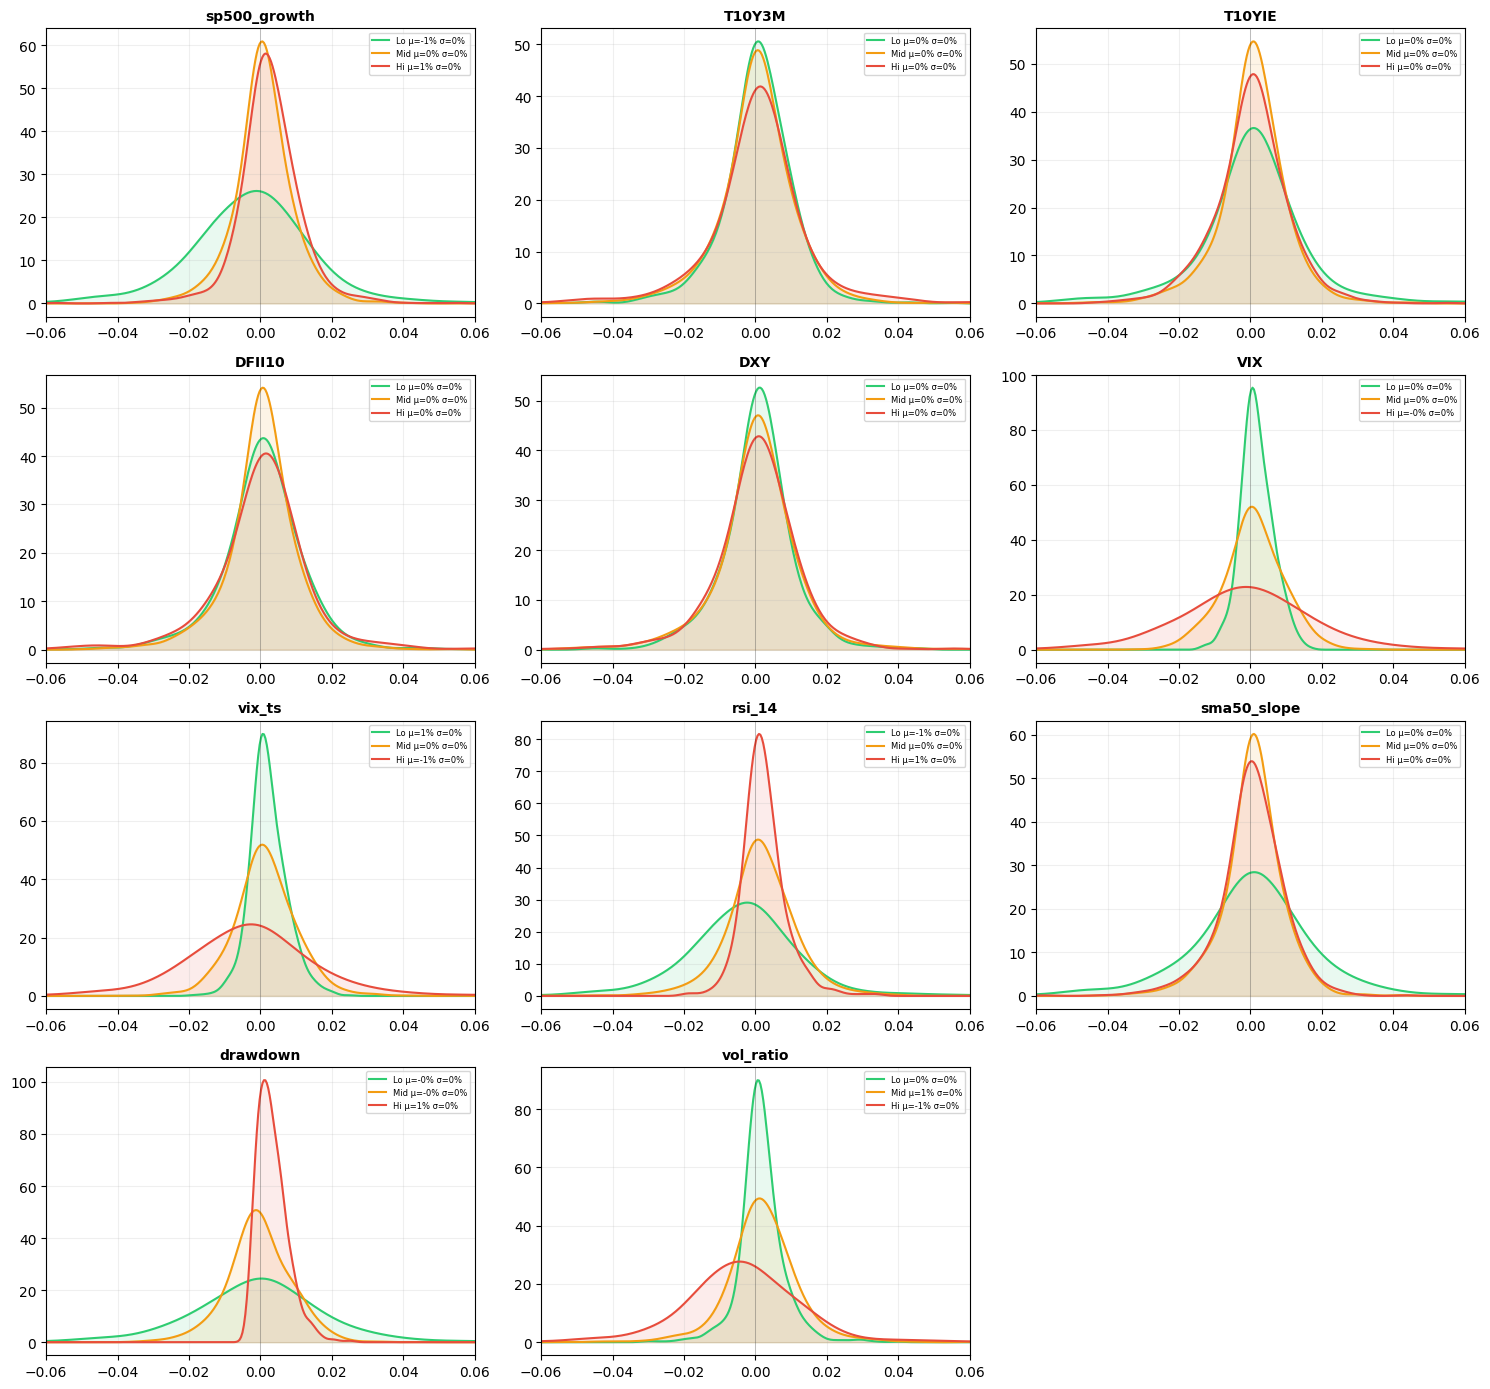

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
ret = df['spy_ret'].values
x_grid = np.linspace(-0.06, 0.06, 300)
colors = {'Lo': '#2ecc71', 'Mid': '#f39c12', 'Hi': '#e74c3c'}

for i, col in enumerate(STATE_VARS):
    ax = axes[i]
    vals = df[col].values
    ok = ~np.isnan(vals) & ~np.isnan(ret)
    v, r = vals[ok], ret[ok]
    p25, p75 = np.percentile(v, 25), np.percentile(v, 75)

    for label, mask in [('Lo', v <= p25), ('Mid', (v > p25) & (v <= p75)), ('Hi', v > p75)]:
        rs = r[mask]
        if len(rs) < 30:
            continue
        kde = gaussian_kde(rs, bw_method=0.3)
        d = kde(x_grid)
        ax.plot(x_grid, d, color=colors[label], lw=1.5,
                label=f'{label} μ={rs.mean()*252:.0f}% σ={rs.std()*np.sqrt(252):.0f}%')
        ax.fill_between(x_grid, d, alpha=0.1, color=colors[label])

    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.axvline(0, color='black', lw=0.5, alpha=0.3)
    ax.legend(fontsize=6)
    ax.set_xlim(-0.06, 0.06)
    ax.grid(True, alpha=0.2)

axes[11].set_visible(False)
plt.tight_layout()
plt.show()

## 4 — State Classification

In [5]:
var_arrays = {col: df[col].values for col in STATE_VARS}
spy_lr = df['spy_log_ret'].values
states = np.full(N, -1, dtype=int)

for t in range(WINDOW, N):
    ws = t - WINDOW
    levels = []
    valid = True

    for k, col in enumerate(STATE_VARS):
        vals = var_arrays[col][ws:t + 1]
        if np.isnan(vals).sum() > len(vals) * 0.1:
            valid = False
            break
        v_now = var_arrays[col][t]
        if np.isnan(v_now):
            valid = False
            break
        clean = vals[~np.isnan(vals)]
        p25 = np.percentile(clean, LO_PCT)
        p75 = np.percentile(clean, HI_PCT)
        levels.append(0 if v_now <= p25 else (2 if v_now > p75 else 1))

    if not valid:
        continue

    state = sum(levels[k] * (3 ** k) for k in range(N_VARS))
    states[t] = state

valid_mask = states >= 0
vs = states[valid_mask]
changes = (np.diff(vs) != 0).sum()

print(f'Classified: {valid_mask.sum()} / {N} days')
print(f'Unique states: {len(np.unique(vs))} / {N_STATES:,}')
print(f'Regime changes: {changes} ({changes / len(vs):.1%})')
print(f'Avg holding: {len(vs) / changes:.1f} days')

Classified: 4288 / 4792 days
Unique states: 2350 / 177,147
Regime changes: 3399 (79.3%)
Avg holding: 1.3 days


## 5 — EP + FFR Engine

In [6]:
def compute_ep(log_returns, var_data, states_vec, n_states=N_STATES, min_obs=10):
    """EP with mean equality + variance inequality per state variable."""
    T = len(log_returns)
    ret_df = pd.DataFrame(log_returns, columns=['SPY'])
    p_exp = ft.exp_decay_probs(ret_df, half_life=T / 2)

    var_arrs = list(var_data.values())
    n_v = len(var_arrs)
    states_prob = np.zeros((T, n_states))
    ens = {}

    for state in range(n_states):
        mask = states_vec == state
        n_obs = mask.sum()

        if n_obs < max(min_obs, 2 * n_v):
            states_prob[:, state] = p_exp[:, 0]
            ens[state] = 100.0
            continue

        A_rows = [np.ones((1, T))]
        b_vals = [1.0]
        G_rows = []
        h_vals = []

        for arr in var_arrs:
            mu = np.mean(arr[mask])
            sigma = np.std(arr[mask])
            A_rows.append(arr[np.newaxis, :])
            b_vals.append(mu)
            G_rows.append((arr ** 2)[np.newaxis, :])
            h_vals.append(sigma ** 2 + mu ** 2)

        A = np.vstack(A_rows)
        b = np.array(b_vals).reshape(-1, 1)
        G = np.vstack(G_rows)
        h = np.array(h_vals).reshape(-1, 1)

        try:
            q = ft.entropy_pooling(p_exp, A, b, G, h)
            states_prob[:, state] = q[:, 0]
            re = float(q.T @ (np.log(q + 1e-30) - np.log(p_exp + 1e-30)))
            ens[state] = np.exp(-re) * 100
        except Exception:
            states_prob[:, state] = p_exp[:, 0]
            ens[state] = 100.0

    return states_prob, ens


def ffr_simulate(S, H, init_state, states_prob, states_vec, log_returns):
    """Vectorized FFR: S paths of H days, state-dependent resampling."""
    T = len(log_returns)
    idx = np.arange(T)
    sim = np.zeros((S, H))
    cs = np.full(S, init_state, dtype=int)

    for h in range(H):
        for state in np.unique(cs):
            in_s = cs == state
            p = np.maximum(states_prob[:, state], 0)
            ps = p.sum()
            p = p / ps if ps > 0 else np.ones(T) / T
            chosen = np.random.choice(idx, size=in_s.sum(), p=p)
            sim[in_s, h] = log_returns[chosen]
            cs[in_s] = states_vec[chosen]

    return sim.sum(axis=1)


def compute_cvar(returns, alpha=ALPHA):
    """CVaR (expected shortfall)."""
    thr = np.percentile(returns, (1 - alpha) * 100)
    tail = returns[returns <= thr]
    return -tail.mean() if len(tail) > 0 else 0.0


def cvar_pct_rank(val, history):
    """Percentile rank within history."""
    arr = np.array(history)
    if len(arr) < 2:
        return 0.5
    return (np.sum(arr < val) + 0.5 * np.sum(arr == val)) / len(arr)


print('Engine defined.')

Engine defined.


## 6 — Walk-Forward Backtest

In [7]:
np.random.seed(SEED)
t0 = time.time()

# Phase boundaries — anchor to first valid state
first_valid = np.where(states >= 0)[0][0]
phase1_start = first_valid + PHASE0_DAYS
phase2_start = phase1_start + PHASE1_DAYS

print(f'Phase 0: {df.index[first_valid].date()} → {df.index[phase1_start - 1].date()}')
print(f'Phase 1: {df.index[phase1_start].date()} → {df.index[phase2_start - 1].date()}')
print(f'Phase 2: {df.index[phase2_start].date()} → {df.index[-1].date()}')


def run_ffr(t, current_state):
    """EP + FFR at time t for given state. Returns CVaR and ENS."""
    ws = max(0, t + 1 - WINDOW)
    lr_w = spy_lr[ws:t + 1]
    vd = {col: var_arrays[col][ws:t + 1] for col in STATE_VARS}
    st_w = states[ws:t + 1]
    sp, ens = compute_ep(lr_w, vd, st_w)
    cum_ret = ffr_simulate(S_SIM, H, current_state, sp, st_w, lr_w)
    return compute_cvar(cum_ret), ens.get(current_state, 100.0)


# ── Phase 1 ──────────────────────────────────────────────────────
print(f'\n=== Phase 1: CVaR Collection ===')
cvar_pool = []
records = []
prev = states[phase1_start - 1] if states[phase1_start - 1] >= 0 else 0
ffr1 = 0

for t in range(phase1_start, phase2_start):
    cs = states[t]
    if cs < 0:
        continue
    if cs != prev:
        cv, ens_val = run_ffr(t, cs)
        cvar_pool.append(cv)
        ffr1 += 1
        records.append({'date': df.index[t], 'phase': 1, 'state': cs,
                        'cvar': cv, 'rank': np.nan, 'ens': ens_val})
        if ffr1 % 20 == 0:
            print(f'  #{ffr1} | {df.index[t].date()} | CVaR={cv:.4f}')
    prev = cs

print(f'Phase 1: {ffr1} FFR runs → {len(cvar_pool)} CVaR obs')
if cvar_pool:
    print(f'CVaR range: [{min(cvar_pool):.4f}, {max(cvar_pool):.4f}]')
print(f'Time: {time.time() - t0:.0f}s')

# ── Phase 2 ──────────────────────────────────────────────────────
print(f'\n=== Phase 2: Live Evaluation ===')
ffr2 = 0

for t in range(phase2_start, N):
    cs = states[t]
    if cs < 0:
        continue
    if cs != prev:
        cv, ens_val = run_ffr(t, cs)
        cvar_pool.append(cv)

        # Rolling 504d percentile rank
        pool_window = cvar_pool[-CVAR_RANK_WINDOW:]
        rank = cvar_pct_rank(cv, pool_window)

        ffr2 += 1
        records.append({'date': df.index[t], 'phase': 2, 'state': cs,
                        'cvar': cv, 'rank': rank, 'ens': ens_val})
        if ffr2 % 50 == 0:
            print(f'  #{ffr2} | {df.index[t].date()} | CVaR={cv:.4f} | '
                  f'rank={rank:.2f} | pool={len(pool_window)}')
    prev = cs

rebal = pd.DataFrame(records).set_index('date')
print(f'\nPhase 2: {ffr2} FFR runs')
print(f'Total: {len(rebal)} FFR runs, {len(cvar_pool)} CVaR obs')
print(f'Time: {time.time() - t0:.0f}s')

Phase 0: 2009-03-03 → 2011-03-01
Phase 1: 2011-03-02 → 2013-03-04
Phase 2: 2013-03-05 → 2026-03-18

=== Phase 1: CVaR Collection ===
  #20 | 2011-04-04 | CVaR=0.0548
  #40 | 2011-05-11 | CVaR=0.0529
  #60 | 2011-06-20 | CVaR=0.0587
  #80 | 2011-07-20 | CVaR=0.0497
  #100 | 2011-09-08 | CVaR=0.0757
  #120 | 2011-10-17 | CVaR=0.0831
  #140 | 2011-11-15 | CVaR=0.0871
  #160 | 2011-12-19 | CVaR=0.0844
  #180 | 2012-01-27 | CVaR=0.0781
  #200 | 2012-02-29 | CVaR=0.0745
  #220 | 2012-04-02 | CVaR=0.0788
  #240 | 2012-05-04 | CVaR=0.0694
  #260 | 2012-06-19 | CVaR=0.0738
  #280 | 2012-07-25 | CVaR=0.0753
  #300 | 2012-08-24 | CVaR=0.0629
  #320 | 2012-09-28 | CVaR=0.0622
  #340 | 2012-11-01 | CVaR=0.0631
  #360 | 2012-12-05 | CVaR=0.0617
  #380 | 2013-01-07 | CVaR=0.0701
  #400 | 2013-02-08 | CVaR=0.0711
Phase 1: 411 FFR runs → 411 CVaR obs
CVaR range: [0.0462, 0.0944]
Time: 271s

=== Phase 2: Live Evaluation ===
  #50 | 2013-05-28 | CVaR=0.0517 | rank=0.04 | pool=461
  #100 | 2013-09-04 | CV

## 7 — Leverage & Backtest

In [8]:
eval_start = df.index[phase2_start]
eval_dates = df.index[df.index >= eval_start]
eval_ffr = rebal[rebal['phase'] == 2]

# ── Daily rank: signal at t applied at t+1 (no look-ahead) ──────
daily_rank = pd.Series(np.nan, index=eval_dates)
daily_rank.iloc[0] = 0.5

for d in eval_ffr.index:
    if d in daily_rank.index:
        pos = daily_rank.index.get_loc(d)
        if pos + 1 < len(daily_rank):
            daily_rank.iloc[pos + 1] = eval_ffr.loc[d, 'rank']

daily_rank = daily_rank.ffill()

# SMA bear: t-1 close vs t-1 SMA (known at open of t)
sma_bear = (df['SPY'].shift(1) < df['sma_200'].shift(1)).reindex(eval_dates).fillna(False)


def rank_to_lev(r, bear):
    if bear:
        return 0.0
    if r < RANK_LO:
        return LEV_CALM
    elif r < RANK_HI:
        return LEV_NORMAL
    else:
        return LEV_STRESS


daily_lev = pd.Series(
    [rank_to_lev(r, b) for r, b in zip(daily_rank, sma_bear)],
    index=eval_dates)

# ── Backtest function ────────────────────────────────────────────
eval_df = df.loc[eval_start:].copy()


def backtest(lev_series, name):
    eq = 1.0
    prev_l = 0.0
    recs = []
    for d in eval_df.index:
        l = lev_series.get(d, prev_l)
        tc = TC_BPS * abs(l - prev_l) * eq if l != prev_l else 0.0
        eq -= tc
        r = eval_df.loc[d, 'spy_ret']
        eq *= (1 + l * r)
        recs.append({'date': d, 'leverage': l, 'equity': eq,
                     'daily_ret': l * r, 'tc': tc})
        prev_l = l
    return pd.DataFrame(recs).set_index('date')


bt_ep = backtest(daily_lev, 'EP Throttle')
bt_sma = backtest(pd.Series(np.where(sma_bear, 0.0, 1.0), index=eval_dates), 'SMA-Only')
bt_bh = backtest(pd.Series(1.0, index=eval_dates), 'B&H')
strats = {'EP Throttle': bt_ep, 'SMA-Only': bt_sma, 'B&H': bt_bh}

# ── Metrics ──────────────────────────────────────────────────────
print(f"{'='*70}")
print('Performance (net of 10bps TC)')
print(f"{'='*70}")

for name, bt in strats.items():
    ny = len(bt) / 252
    tr = bt['equity'].iloc[-1] - 1
    ar = (1 + tr) ** (1 / ny) - 1
    av = bt['daily_ret'].std() * np.sqrt(252)
    sh = ar / av if av > 0 else 0
    dd = ((bt['equity'] - bt['equity'].cummax()) / bt['equity'].cummax()).min()
    cal = ar / abs(dd) if dd != 0 else 0
    al = bt['leverage'].mean()
    print(f'  {name:15s} | Ret={ar:>7.2%} | Vol={av:>7.2%} | '
          f'Sharpe={sh:.2f} | DD={dd:>8.2%} | Calmar={cal:.2f} | AvgLev={al:.2f}')

print(f'\nLeverage distribution:')
for lev in sorted(daily_lev.unique()):
    n = (daily_lev == lev).sum()
    print(f'  {lev:.1f}x: {n:5d} days ({n / len(daily_lev):.1%})')

Performance (net of 10bps TC)
  EP Throttle     | Ret=  9.27% | Vol= 13.05% | Sharpe=0.71 | DD= -22.80% | Calmar=0.41 | AvgLev=0.95
  SMA-Only        | Ret= 10.47% | Vol= 11.67% | Sharpe=0.90 | DD= -21.55% | Calmar=0.49 | AvgLev=0.85
  B&H             | Ret= 13.93% | Vol= 16.93% | Sharpe=0.82 | DD= -33.72% | Calmar=0.41 | AvgLev=1.00

Leverage distribution:
  0.0x:   496 days (15.1%)
  0.5x:   466 days (14.2%)
  1.0x:  1213 days (37.0%)
  1.5x:  1105 days (33.7%)


## 8 — Plots

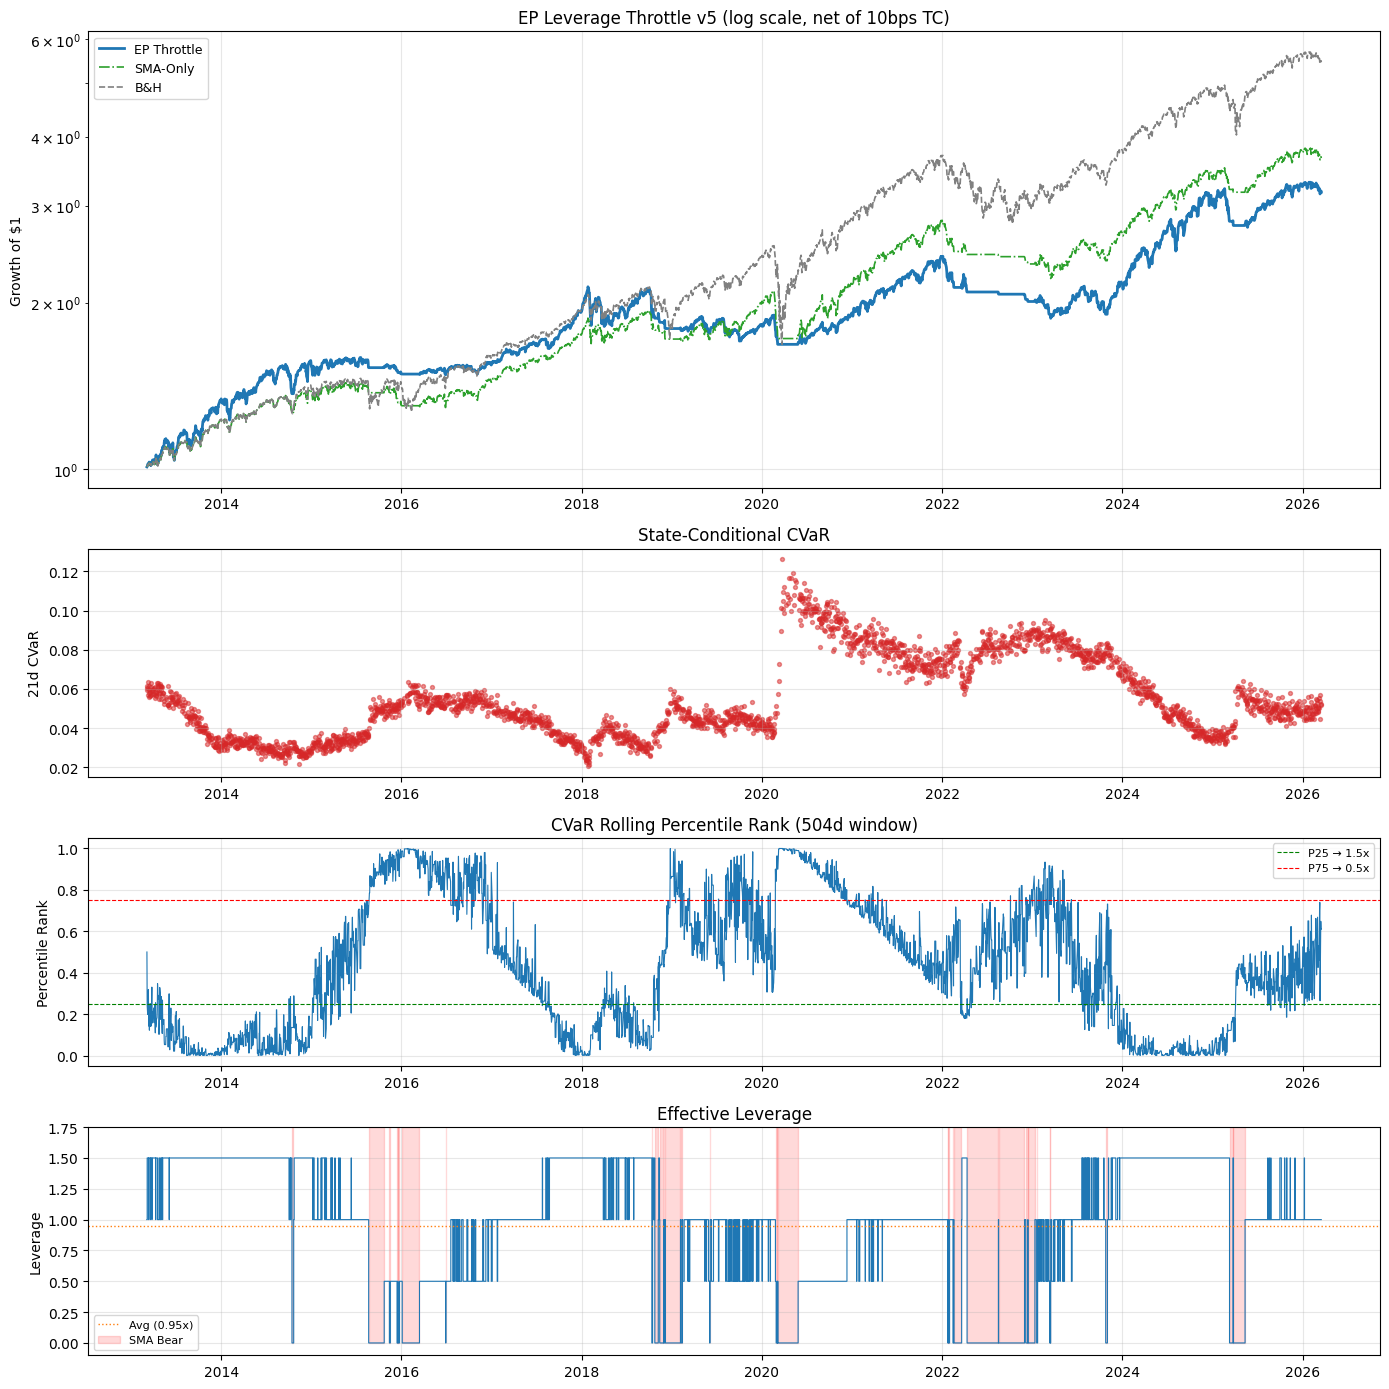

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14),
                         gridspec_kw={'height_ratios': [3, 1.5, 1.5, 1.5]})

# Equity curves
ax = axes[0]
styles = {'EP Throttle': ('C0', '-', 2), 'SMA-Only': ('C2', '-.', 1.2), 'B&H': ('grey', '--', 1.2)}
for name, bt in strats.items():
    c, ls, lw = styles[name]
    ax.plot(bt.index, bt['equity'], label=name, color=c, ls=ls, lw=lw)
ax.set_yscale('log')
ax.set_title('EP Leverage Throttle v5 (log scale, net of 10bps TC)')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# CVaR over time
ax = axes[1]
colors_state = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
p2 = rebal[rebal['phase'] == 2]
ax.scatter(p2.index, p2['cvar'], s=8, c='C3', alpha=0.5)
ax.set_ylabel('21d CVaR')
ax.set_title('State-Conditional CVaR')
ax.grid(True, alpha=0.3)

# Rank
ax = axes[2]
ax.plot(daily_rank.index, daily_rank, lw=0.8, color='C0')
ax.axhline(RANK_LO, color='green', ls='--', lw=0.8, label=f'P{int(RANK_LO*100)} → {LEV_CALM}x')
ax.axhline(RANK_HI, color='red', ls='--', lw=0.8, label=f'P{int(RANK_HI*100)} → {LEV_STRESS}x')
ax.set_ylabel('Percentile Rank')
ax.set_ylim(-0.05, 1.05)
ax.set_title('CVaR Rolling Percentile Rank (504d window)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Leverage
ax = axes[3]
ax.step(daily_lev.index, daily_lev.values, where='post', lw=0.8, color='C0')
avg_l = daily_lev.mean()
ax.axhline(avg_l, color='C1', ls=':', lw=1, label=f'Avg ({avg_l:.2f}x)')
ax.fill_between(daily_lev.index, 0, 1.75,
                where=sma_bear, alpha=0.15, color='red', label='SMA Bear')
ax.set_ylabel('Leverage')
ax.set_ylim(-0.1, 1.75)
ax.set_title('Effective Leverage')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

for a in axes:
    a.xaxis.set_major_locator(mdates.YearLocator(2))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 9 — Crisis Analysis

In [10]:
crises = [
    ('COVID',      '2020-02-19', '2020-03-23'),
    ('2022 Bear',  '2022-01-03', '2022-10-12'),
    ('2018 Q4',    '2018-09-20', '2018-12-24'),
    ('2015-16',    '2015-08-17', '2016-02-11'),
    ('2011 EU',    '2011-07-07', '2011-10-03'),
]

rows = []
for crisis, start, end in crises:
    row = {'Crisis': crisis}
    for name, bt in strats.items():
        sub = bt[(bt.index >= start) & (bt.index <= end)]
        if len(sub) > 0:
            dd = ((sub['equity'] - sub['equity'].cummax()) / sub['equity'].cummax()).min()
            row[name] = f'{dd:.2%}'
        else:
            row[name] = 'N/A'
    rows.append(row)

print(pd.DataFrame(rows).set_index('Crisis').to_string())

          EP Throttle SMA-Only      B&H
Crisis                                 
COVID         -11.50%  -17.84%  -33.72%
2022 Bear     -14.63%  -14.06%  -24.50%
2018 Q4       -15.36%  -11.31%  -19.35%
2015-16        -5.80%   -8.35%  -12.82%
2011 EU           N/A      N/A      N/A
